<a href="https://colab.research.google.com/github/Azyur-i/CS182-03/blob/main/FA3/CO1FA3_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Made by Heughric Fernando and Jan Christian Diesta (Group 7)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

db = 'updated_pollution_dataset.csv'
data = pd.read_csv(db)
data.head()


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


- This cell imports essential libraries like Pandas and NumPy for data manipulation and Matplotlib/Seaborn for visualization
- It also loads specific modules from Scikit-Learn to handle data scaling, model splitting, and SVM classification
- It uses data.head() to display the first five rows of the data to verify the columns and content

# Data Visualization

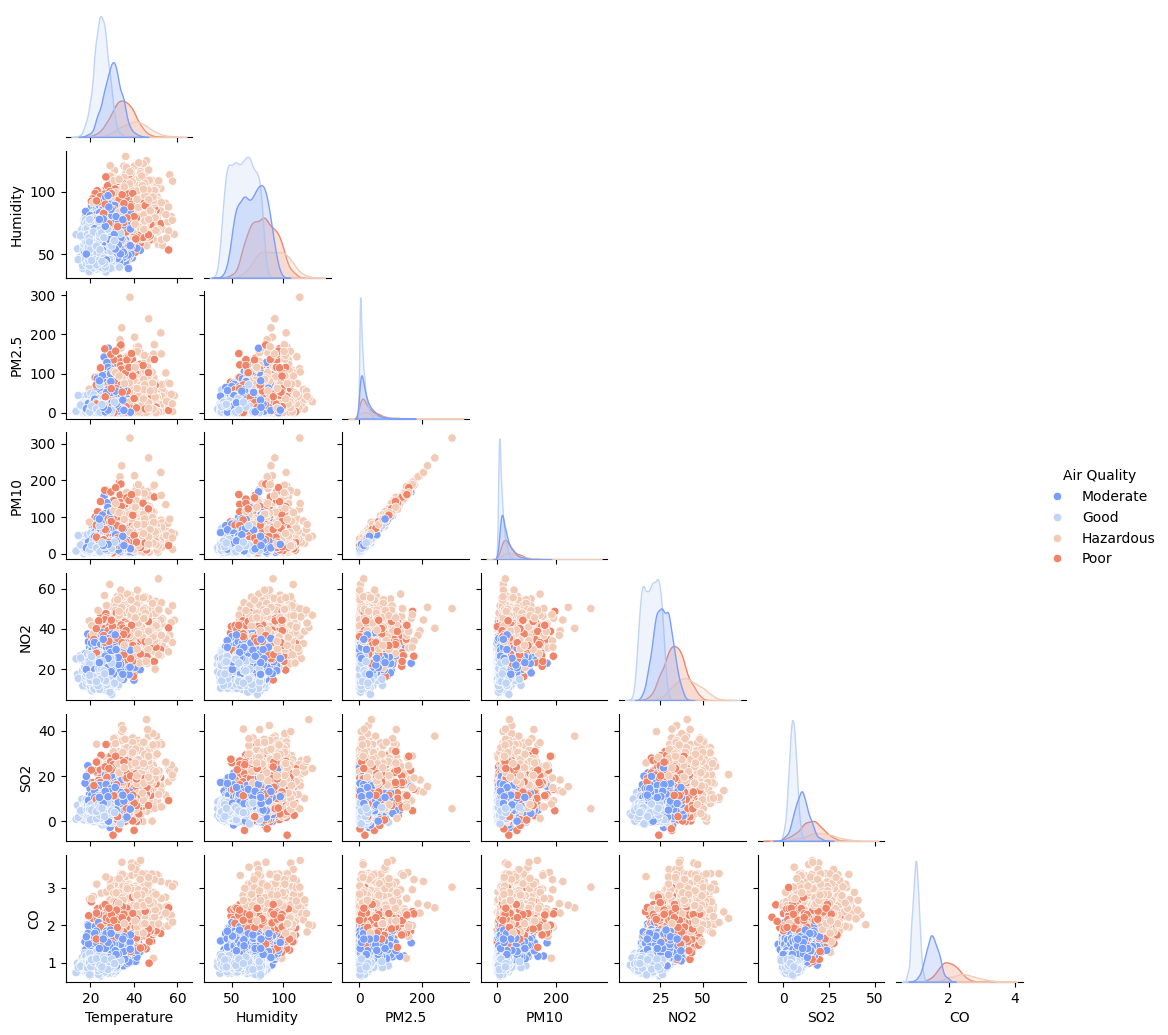

In [12]:
plotdata=data[['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO','Air Quality']]

sns.pairplot(plotdata, hue='Air Quality', corner=True, height=1.5, palette='coolwarm')
plt.show()

- A subset of pollutant and weather variables is selected to analyze their relationships
- The code generates a pair plot, coloring the data points based on different "Air Quality" categories

# SVM Model 1 With 3 Features

In [13]:
# Label Encoder for both Models

le = LabelEncoder()
y_encoded = le.fit_transform(data['Air Quality'])

- A LabelEncoder is initialized to convert categorical air quality strings into numerical format
- The code fits and transforms the 'Air Quality' column so the SVM model can process the target labels
- The resulting numerical values are stored in y_encoded for use in the training process

In [14]:
# 1st Model (3 features)

features1 = ['PM2.5', 'PM10', 'NO2']
X1 = data[features1]
Y1 = y_encoded

# Splitting 1st Model Data

X1_train, X1_test, Y1_train, Y1_test = train_test_split(
    X1, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print("Training set size:",X1_train.shape)
print("Testing set size:",X1_test.shape)

Training set size: (3500, 3)
Testing set size: (1500, 3)


- The first model is defined using only three specific pollutant features: PM2.5, PM10, and NO2
- The dataset is divided into training and testing sets using a 70/30 split ratio
- Stratification is applied to ensure that the proportion of air quality classes remains consistent in both sets
- The cell prints the final sizes of the training and testing matrices to confirm the split

In [15]:
# Scaling 1st Model Data

scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Training 1st Model Data

model1 = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
model1.fit(X1_train_scaled, Y1_train)
Y1_pred = model1.predict(X1_test_scaled)
model1.score(X1_test_scaled, Y1_test)

0.7413333333333333

- A StandardScaler is created to normalize the feature values to a common scale with a mean of 0
- The scaler is fitted on the training data and then applied to both the training and test sets
- An SVM classifier with an RBF kernel is initialized and trained using the scaled 3-feature data

# SVM Model 2 With 6 or More Features

In [16]:
# 2nd model

features2 = ['Temperature','Humidity','PM2.5','PM10','NO2','SO2','CO']
X2 = data[features2]
Y2 = data['Air Quality']

# Splitting the dataset into training and testing sets

X2_train, X2_test, Y2_train, Y2_test = train_test_split(
    X2, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print("Training set size:",X2_train.shape)
print("Testing set size:",X2_test.shape)


Training set size: (3500, 7)
Testing set size: (1500, 7)


- A second set of features is defined, expanding the input to include temperature, humidity, and additional pollutants
- These seven features are assigned to $X_2$ to create a more comprehensive input dataset
- The expanded 7-feature dataset is split into training and testing subsets using the same 70/30 ratio

In [17]:
# Scaling to ensure all features are in the same scale
# Training the Data

scaler=StandardScaler()
x2_train_scaled = scaler.fit_transform(X2_train)
x2_test_scaled = scaler.transform(X2_test)

model2 = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
model2.fit(x2_train_scaled, Y2_train)
Y2_pred = model2.predict(x2_test_scaled)
model2.score(x2_test_scaled ,Y2_test)

0.9226666666666666

- The 7-feature data is standardized using a new scaler to ensure all environmental variables are weighted equally
- A second SVM model is trained using this expanded feature set and the RBF kernel
- Predictions are generated for the second model, and a performance score is calculated for the test data

# Model Performance Visualization and Evaluation


==================== Model 1 (3 Features: PM2.5, PM10, NO2) ====================
Accuracy: 74.13%
              precision    recall  f1-score   support

        Good       0.85      0.93      0.89       600
   Hazardous       0.72      0.42      0.53       150
    Moderate       0.68      0.71      0.69       450
        Poor       0.59      0.57      0.58       300

    accuracy                           0.74      1500
   macro avg       0.71      0.66      0.67      1500
weighted avg       0.74      0.74      0.73      1500



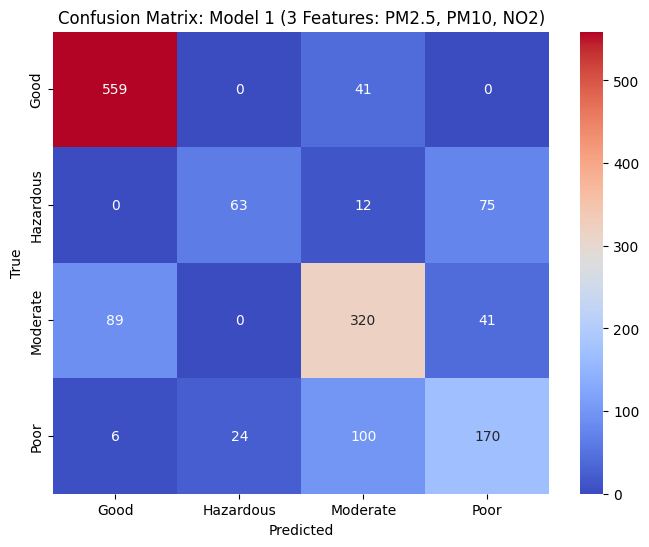


==================== Model 2 (7 Features) ====================
Accuracy: 92.27%
              precision    recall  f1-score   support

        Good       0.99      0.99      0.99       600
   Hazardous       0.86      0.76      0.81       150
    Moderate       0.93      0.93      0.93       450
        Poor       0.81      0.84      0.83       300

    accuracy                           0.92      1500
   macro avg       0.90      0.88      0.89      1500
weighted avg       0.92      0.92      0.92      1500



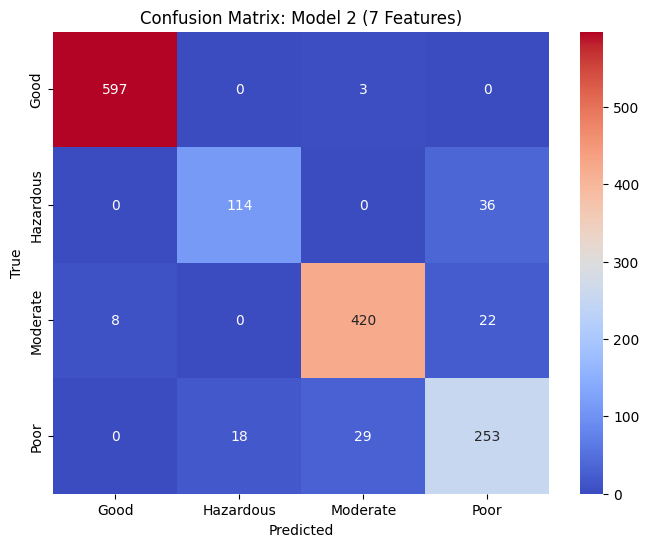

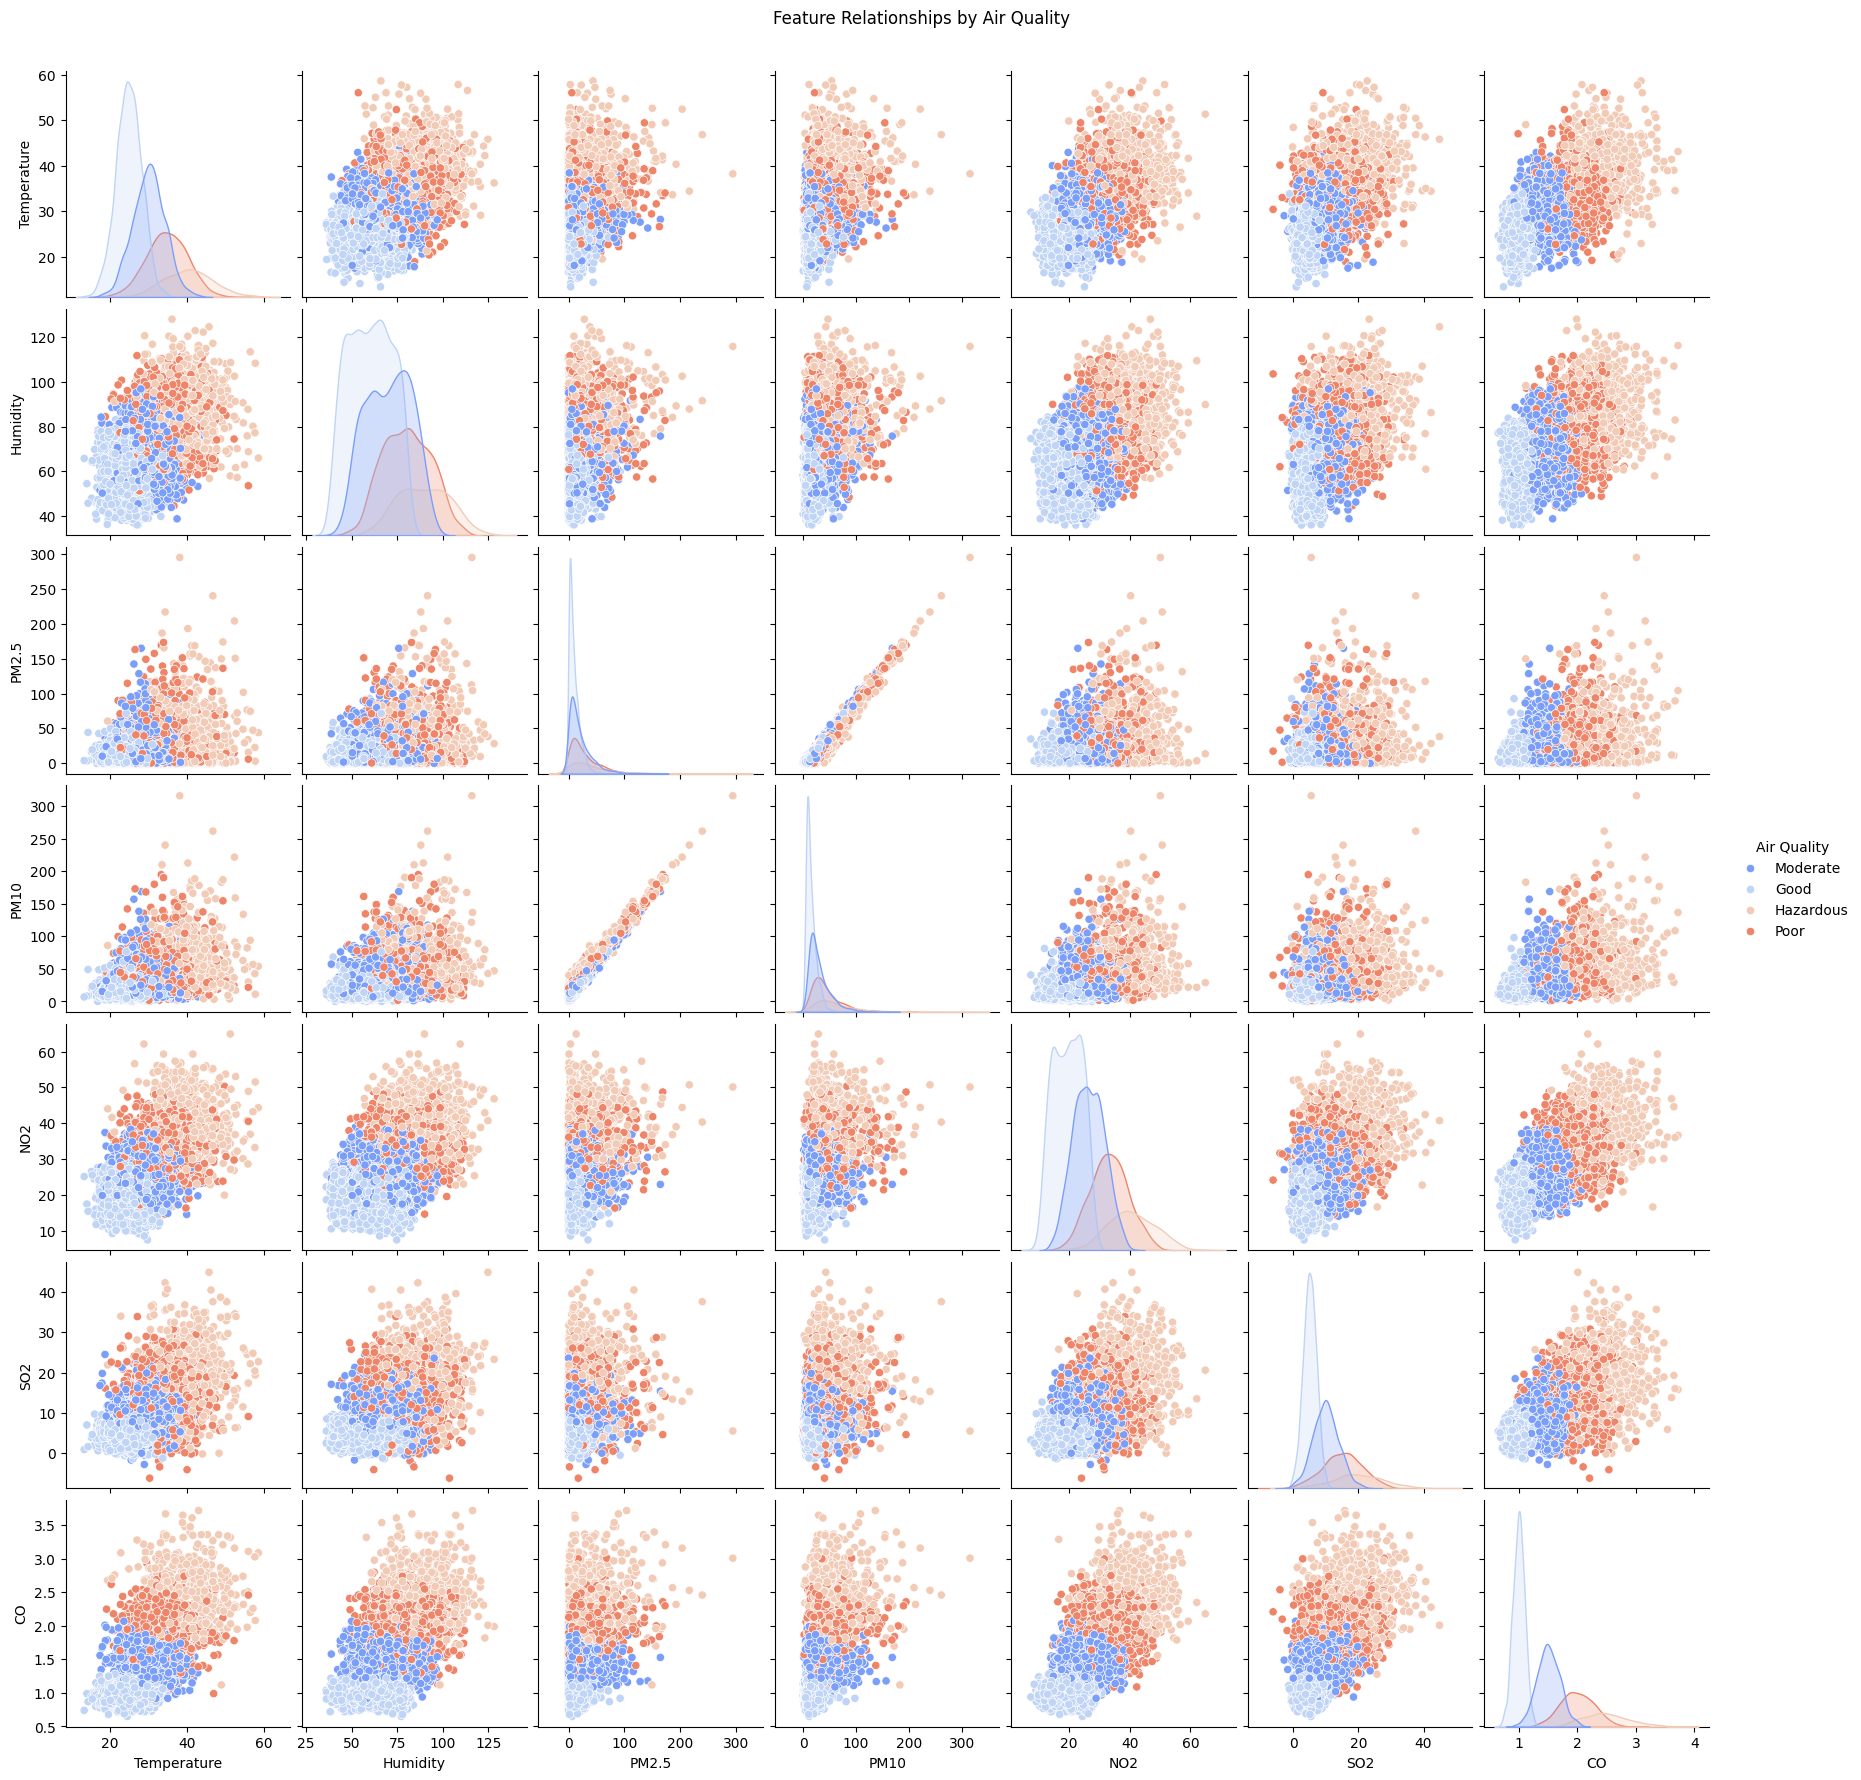

In [18]:
def evaluate_model(y_test, y_pred, title):
    print(f"\n{'='*20} {title} {'='*20}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix: {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

evaluate_model(Y1_test, Y1_pred, "Model 1 (3 Features: PM2.5, PM10, NO2)")
evaluate_model(Y2_test, Y2_pred, "Model 2 (7 Features)")

plotdata = data[['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Air Quality']]
sns.pairplot(plotdata, hue='Air Quality', palette='coolwarm')
plt.suptitle("Feature Relationships by Air Quality", y=1.02)
plt.show()

- A custom function is defined to print a detailed classification report including precision, recall, and F1-score
- The function generates a heatmap-based confusion matrix to visualize correct and incorrect predictions for each class.
- This function is called for both Model 1 and Model 2 to compare their diagnostic performance side-by-side.